In [1]:
"""
Этап 2. Базовая картина бизнеса.

Что считаем:
- Уникальные SKU, заказы, покупатели.
- Общая выручка, количество единиц.
- Средний чек (на уровне заказа, не строки).
- Динамика по месяцам.
- Концентрация выручки на топ-товарах.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 13

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
summary = read_sql("""
    SELECT
        COUNT(DISTINCT stock_code)         AS unique_skus,
        COUNT(DISTINCT invoice_no)         AS unique_invoices,
        COUNT(DISTINCT customer_id)        AS unique_customers,
        SUM(quantity)                      AS total_units,
        ROUND(SUM(revenue)::numeric, 2)    AS total_revenue,
        COUNT(*)                           AS total_rows
    FROM sales;
""")
print("Ключевые метрики магазина (весь период 2009-12 — 2011-12):")
display(summary.T)

Ключевые метрики магазина (весь период 2009-12 — 2011-12):


,0
unique_skus,4895
unique_invoices,39526
unique_customers,5852
total_units,11402616
total_revenue,20109033.72
total_rows,1036925


In [3]:
# Шаг 1: агрегируем выручку по заказу
invoice_totals = read_sql("""
    SELECT
        invoice_no,
        SUM(revenue)                AS invoice_revenue,
        SUM(quantity)               AS invoice_units,
        COUNT(*)                    AS lines_in_invoice,
        COUNT(DISTINCT stock_code)  AS distinct_skus_in_invoice
    FROM sales
    GROUP BY invoice_no;
""")

# Шаг 2: считаем средние
avg_check = invoice_totals["invoice_revenue"].mean()
median_check = invoice_totals["invoice_revenue"].median()
avg_lines = invoice_totals["lines_in_invoice"].mean()

print(f"Средний чек (average):        £{avg_check:,.2f}")
print(f"Медианный чек (median):       £{median_check:,.2f}")
print(f"Среднее число строк в заказе: {avg_lines:.2f}")
print(f"\nВсего заказов: {len(invoice_totals):,}")

print("\nРаспределение чеков (квантили):")
display(invoice_totals["invoice_revenue"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(2).to_frame("invoice_revenue"))

Средний чек (average):        £508.75
Медианный чек (median):       £303.18
Среднее число строк в заказе: 26.23

Всего заказов: 39,526

Распределение чеков (квантили):


,invoice_revenue
count,39526
unique,26911
top,15.00
freq,60


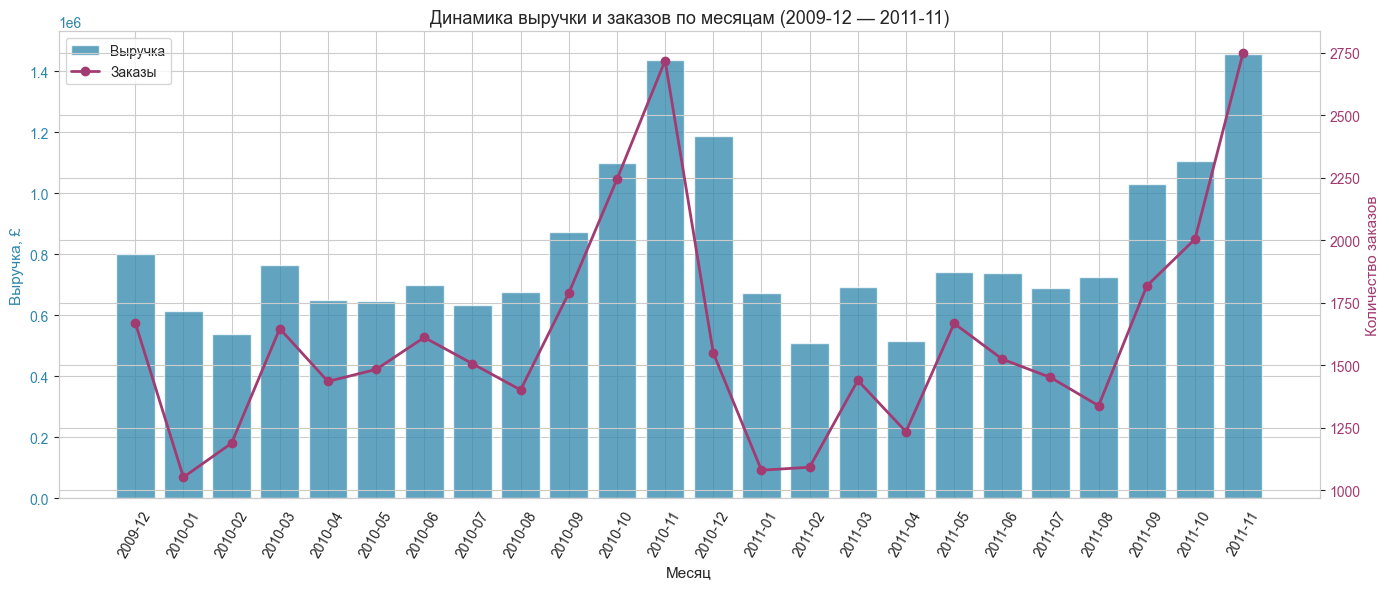


Топ-5 месяцев по выручке:


,month_start,revenue,invoices
23,2011-11-01,"1,457,333.03",2751
11,2010-11-01,"1,435,680.12",2719
12,2010-12-01,"1,187,160.88",1550
22,2011-10-01,"1,106,542.32",2005
10,2010-10-01,"1,098,017.67",2244



Топ-5 месяцев по количеству заказов:


,month_start,revenue,invoices
23,2011-11-01,"1,457,333.03",2751
11,2010-11-01,"1,435,680.12",2719
10,2010-10-01,"1,098,017.67",2244
22,2011-10-01,"1,106,542.32",2005
21,2011-09-01,"1,030,347.86",1818


In [7]:
monthly = read_sql("""
    SELECT
        month_start,
        COUNT(DISTINCT invoice_no)              AS invoices,
        COUNT(DISTINCT customer_id)             AS customers,
        SUM(quantity)                           AS units,
        ROUND(SUM(revenue)::numeric, 2)         AS revenue
    FROM sales
    GROUP BY month_start
    ORDER BY month_start;
""")

# Конвертируем типы
monthly["month_start"] = pd.to_datetime(monthly["month_start"])
monthly["revenue"] = monthly["revenue"].astype(float)

# Исключаем декабрь 2011 (неполный)
monthly_full = monthly[monthly["month_start"] < pd.Timestamp("2011-12-01")].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

color_rev = "#2E86AB"
color_inv = "#A23B72"

# Столбцы выручки
bars = ax1.bar(
    monthly_full["month_start"].dt.strftime("%Y-%m"),
    monthly_full["revenue"],
    color=color_rev, alpha=0.75, label="Выручка",
)
ax1.set_xlabel("Месяц", fontsize=11)
ax1.set_ylabel("Выручка, £", color=color_rev, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_rev)
ax1.tick_params(axis="x", rotation=60)

# Линия заказов на второй оси
ax2 = ax1.twinx()
ax2.plot(
    monthly_full["month_start"].dt.strftime("%Y-%m"),
    monthly_full["invoices"],
    color=color_inv, marker="o", linewidth=2, label="Заказы",
)
ax2.set_ylabel("Количество заказов", color=color_inv, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_inv)

# Заголовок и легенда
plt.title("Динамика выручки и заказов по месяцам (2009-12 — 2011-11)", fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
# Создаём папку reports, если её нет
REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "monthly_dynamics.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nТоп-5 месяцев по выручке:")
display(monthly_full.nlargest(5, "revenue")[["month_start", "revenue", "invoices"]])

print("\nТоп-5 месяцев по количеству заказов:")
display(monthly_full.nlargest(5, "invoices")[["month_start", "revenue", "invoices"]])

In [5]:
top_skus = read_sql("""
    SELECT
        s.stock_code,
        s.description,
        COUNT(DISTINCT s.invoice_no)     AS orders,
        SUM(s.quantity)                  AS units,
        ROUND(SUM(s.revenue)::numeric, 2) AS revenue,
        ROUND(
            (SUM(s.revenue) / (SELECT SUM(revenue) FROM sales) * 100)::numeric,
            2
        ) AS revenue_share_pct
    FROM sales s
    GROUP BY s.stock_code, s.description
    ORDER BY revenue DESC
    LIMIT 10;
""")
print("Топ-10 SKU по выручке:")
display(top_skus)

Топ-10 SKU по выручке:


,stock_code,description,orders,units,revenue,revenue_share_pct
0,22423,REGENCY CAKESTAND 3 TIER,3918,27577,344563.25,1.71
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5356,96086,262931.16,1.31
2,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60,0.84
3,47566,PARTY BUNTING,2674,28378,149187.05,0.74
4,85099B,JUMBO BAG RED RETROSPOT,3245,78860,148823.92,0.74
5,84879,ASSORTED COLOUR BIRD ORNAMENT,2807,81809,132187.92,0.66
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2018,36581,123141.54,0.61
7,79321,CHILLI LIGHTS,1135,16840,85489.91,0.43
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,247,78033,81700.92,0.41
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,756,32525,74448.92,0.37


Топ 10% SKU (489 шт.) → 62.7% выручки
Топ 20% SKU (979 шт.) → 78.8% выручки
Топ 50% SKU (2,447 шт.) → 95.8% выручки

Для 80% выручки нужно 1,036 SKU (21.2% ассортимента)


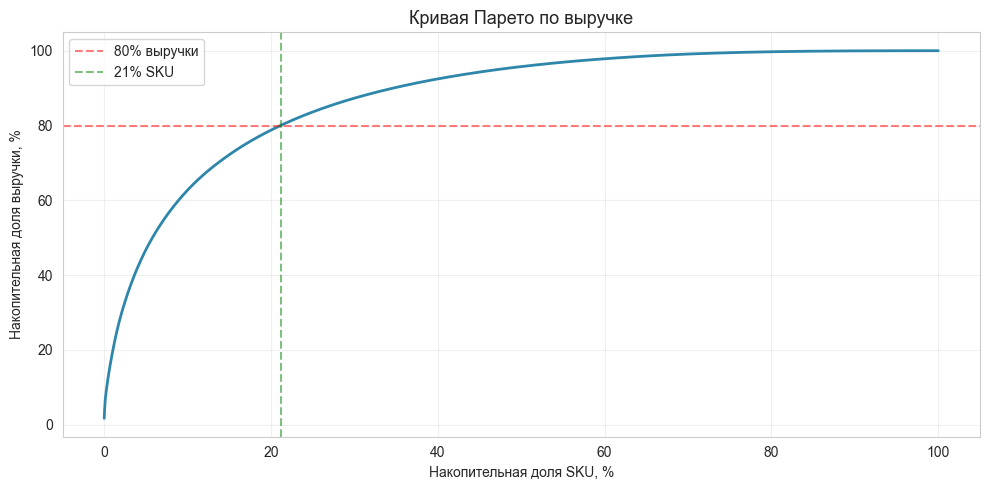

In [6]:
# Выручка по каждому SKU, отсортированная
product_revenue = read_sql("""
    SELECT
        stock_code,
        SUM(revenue) AS revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC;
""")

total_rev = product_revenue["revenue"].sum()
product_revenue["cum_share"] = product_revenue["revenue"].cumsum() / total_rev
product_revenue["sku_share"] = (
    np.arange(1, len(product_revenue) + 1) / len(product_revenue)
)

# Находим, сколько SKU дают 80% выручки
sku_for_80 = (product_revenue["cum_share"] < 0.80).sum() + 1
share_for_80 = sku_for_80 / len(product_revenue)

# Топ-N доля
for pct in [0.1, 0.2, 0.5]:
    n = int(len(product_revenue) * pct)
    cum_share = product_revenue.iloc[n - 1]["cum_share"]
    print(f"Топ {pct:.0%} SKU ({n:,} шт.) → {cum_share:.1%} выручки")

print(f"\nДля 80% выручки нужно {sku_for_80:,} SKU "
      f"({share_for_80:.1%} ассортимента)")

# График Парето
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    product_revenue["sku_share"] * 100,
    product_revenue["cum_share"] * 100,
    linewidth=2, color="#2E86AB",
)
ax.axhline(80, linestyle="--", color="red", alpha=0.5, label="80% выручки")
ax.axvline(share_for_80 * 100, linestyle="--", color="green",
           alpha=0.5, label=f"{share_for_80:.0%} SKU")
ax.set_xlabel("Накопительная доля SKU, %")
ax.set_ylabel("Накопительная доля выручки, %")
ax.set_title("Кривая Парето по выручке")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Этап 2. Базовая картина бизнеса — ВЫВОДЫ (финал)

### Масштаб магазина (2009-12 — 2011-12)
- **4 895 уникальных SKU**
- **39 526 уникальных заказов**
- **5 852 уникальных покупателя**
- **11.4 млн единиц товара**
- **Выручка: £20 109 033.72**

### Средний чек — считаем на уровне заказа
- **Средний чек: £508.75** (раздут крупными оптовыми заказами).
- **Медиана: £303.18** — реальный «типичный» чек.
- **Среднее число строк в заказе: 26.23** — крупные оптовые заказы.
- **Максимум: £168 469.60** — один легендарный заказ (SKU 23843, 80 995 шт.).
- **90% чеков ≤ £925.16**, **1% чеков > £4 173.83** — тяжёлый правый хвост.

**Вывод:** распределение выручки на уровне заказа сильно асимметрично.
Некоторые SKU могут попасть в топ из-за одного-двух крупных оптовых
заказов, а не из-за стабильного спроса.

### Динамика по месяцам
- **Выраженная сезонность:** пики в ноябре-декабре (Рождество),
  спады в январе-феврале.
- Паттерн **повторяется год к году** — сезонность реальная.
- Для XYZ: товары с пиком в декабре покажут высокий CV, но это
  **сезонность, а не хаос**.

### Концентрация выручки (принцип Парето)
| Топ % SKU | Количество | Доля выручки |
|-----------|------------|--------------|
| Топ 10% | 490 | 62.7% |
| Топ 20% | 979 | 78.8% |
| Топ 50% | 2 447 | 95.8% |
| **Для 80% выручки** | **1 036 (21.2%)** | **80%** |

**Вывод:** принцип Парето **подтверждается**: 21.2% ассортимента
дают 80% выручки. Это обосновывает ABC-анализ.

### Аномалии в топ-10
- **SKU 23843 (PAPER CRAFT, LITTLE BIRDIE)** — 1 заказ на £168 470.
  Формально A по выручке, но не отражает реальный спрос.
  В XYZ попадёт в Z (или A-no_data), т.к. продался только в декабре 2011.

### Итеративная очистка данных
Финальные метрики получены после двух итераций очистки:
1. Исключение служебных SKU (POST, DOT, M, ADJUST, gift-сертификаты и др.).
2. Восстановление 36 реальных товаров (кофейные кружки и др.),
   ошибочно отфильтрованных при первой попытке.

**Итоговый sales:** 1 036 925 строк, 4 895 SKU, £20 109 034.

### Что дальше
- **Этап 3 (ABC):** формально разбить 4 895 SKU на A/B/C по выручке.
- **Этап 4 (XYZ):** проверить стабильность спроса по месяцам.
- **Этап 5 (Матрица):** соединить оба анализа → 9 групп → стратегии.